In [ ]:
# Polynomial Regression is a type of regression used when the relationship between input (X) and output (Y) is non-linear.
# Instead of fitting a straight line, it fits a curved line to the data.
# Equation: y=b0​+b1​x+b2​x2+b3​x3+⋯+bn​xn
# x = input feature
# x2,x3= polynomial terms
# b0​= intercept
# b1,b2	​,b3= coefficients

# Coefficient determine the changes of dependent variable cause by one unit change of independent variable
# Intercept is the predicted value of the dependent variable when all independent variables are zero

In [1]:
#  Code Example
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
# Load Dataset
df=pd.read_csv('Ice_cream selling data.csv')
df.head(2)

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120


In [4]:
# Basic information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 2 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Temperature (°C)         49 non-null     float64
 1   Ice Cream Sales (units)  49 non-null     float64
dtypes: float64(2)
memory usage: 916.0 bytes


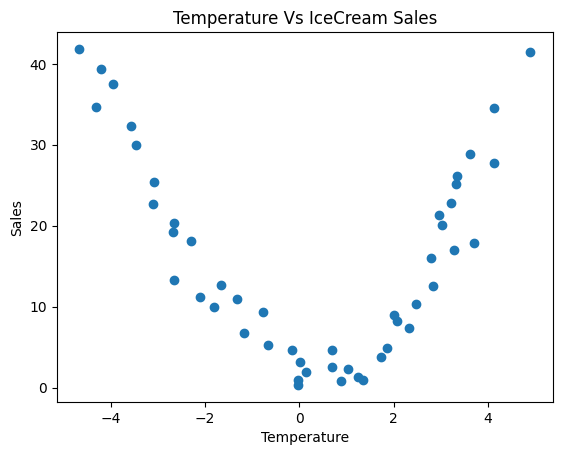

In [6]:
# Show the relationship between input and output variable
plt.Figure(figsize=(5,5))
plt.scatter( df['Temperature (°C)'], df['Ice Cream Sales (units)'])
plt.title('Temperature Vs IceCream Sales')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.show()

In [ ]:
# The relationship between input and output variable is polynomial

In [22]:
# Extract Input and output variable
X=df[['Temperature (°C)']]
y=df[['Ice Cream Sales (units)']]

In [23]:
# Split the data
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [25]:
# Scaled the dataset
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [27]:
# Create extra feature 
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
X_train_poly=poly.fit_transform(X_train_scaled)
X_test_poly=poly.transform(X_test_scaled)

In [28]:
# Now train the model using LinearRegression
from sklearn.linear_model import LinearRegression
lr=LinearRegression()
lr.fit(X_train_poly, y_train)
y_pred=lr.predict(X_test_poly)

In [29]:
# Evaluate the model
from sklearn.metrics import r2_score
print('R2 score:', r2_score(y_test, y_pred))

R2 score: 0.843055137193884


c:\Python3.13.1\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


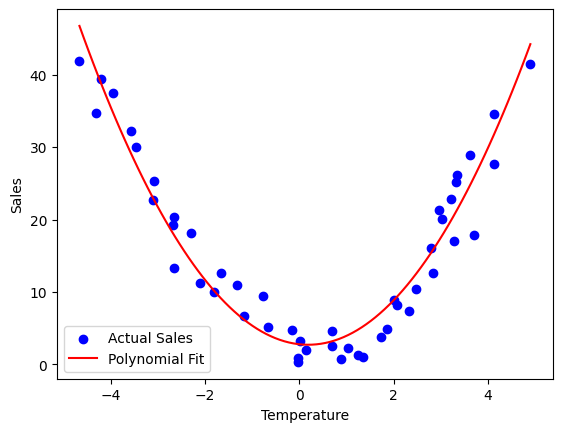

In [30]:
# Create a range of values for a smooth curve
X_range = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
X_range_scaled = scaler.transform(X_range)
X_range_poly = poly.transform(X_range_scaled)

# Predict across the range
y_range_pred = lr.predict(X_range_poly)

# Plotting
plt.scatter(X, y, color='blue', label='Actual Sales')
plt.plot(X_range, y_range_pred, color='red', label='Polynomial Fit')
plt.xlabel('Temperature')
plt.ylabel('Sales')
plt.legend()
plt.show()